# 02 — Del pronóstico semanal al corte diario

(En revisión: desarrollo preliminar y siguientes pasos.) Se conserva el avance y sus resultados; falta profundizar el EDA diario y validar ajustes antes de considerarlo una solución consolidada.

Se compara pronóstico diario autónomo con distribuciones que suman exactamente al pronóstico semanal. Entradas: base diaria/ventanas de 01, base semanal de 10 y pronósticos temporales `Sistema_diario` de 14. No se emplea el total real de la semana para emitir una predicción.

Alcance: H1 semanal, siete días futuros desde cada lunes disponible de 2026. H2–H5 diarios quedan fuera de esta primera evaluación. Los predictores se congelan al lunes: no se incorporan cortes ni clima del martes para predecir el resto de esa misma semana. Una actualización diaria dentro de la semana sería un experimento distinto.

Métodos: reparto uniforme; perfil de volumen reportado por día en ocho semanas anteriores; boosting diario autónomo; boosting reconciliado al total semanal. Todos se puntúan sobre los mismos días con reporte, conservando los días sin dato. La frecuencia histórica de reporte se usa sólo para construir el perfil de reparto, no para declarar ceros productivos.

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from threadpoolctl import threadpool_limits

ROOT = next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"Datos_analiticos_proyecto").is_dir())
SALIDA = ROOT/"Datos_analiticos_proyecto"

KEY=['finca','producto','color','variedad']
DESTINO=SALIDA/'modelo_con_proyecciones_teoricas'
integrados=pd.read_parquet(DESTINO/'base_analitica_proyecciones.parquet')
datos=integrados.loc[integrados.y.notna()&integrados.admisible_modelo].copy()
categoricas=['producto','color','variedad']
temporales=['horizonte','semana_seno','semana_coseno']
memoria=['produccion_lag1','produccion_lag2','produccion_lag3','media_4','media_8','desv_4','tendencia_4_8','cambio_reciente','produccion_52']
climaticas=[v+s for v in ['temperatura_semana','humedad_semana','radiacion_semana'] for s in ['_lag1','_media4']]
agronomicas=[]
X_columnas=categoricas+temporales+memoria+climaticas
X_teoria=X_columnas+['teoria_modelo','antiguedad_curva','desviacion_reciente_teoria']
X_historia=X_teoria+['teoria_previa_1','teoria_previa_2','revision_teoria']
assert 'y' not in X_historia
assert not integrados.duplicated(KEY+['origen','horizonte']).any()

DIARIO=SALIDA/'modelo_diario'
panel=pd.read_parquet(DIARIO/'produccion_clima_diaria.parquet')
f=pd.read_parquet(DIARIO/'features_diarias.parquet').rename(columns={'fecha':'origen'})
diarias=[c for c in f if c not in KEY+['origen']]
pronosticos=pd.read_parquet(DESTINO/'comparacion_features_diarias_2026.parquet')
pronosticos=pronosticos.loc[pronosticos.horizonte.eq(1)]


In [2]:
CORTES = [pd.Timestamp("2025-07-07"),pd.Timestamp("2026-01-05"),pd.Timestamp("2026-05-04")]
SEMANAS_EVALUACION = 8

def crear_modelo(nombre,columnas):
    numericas = [c for c in columnas if c not in categoricas]
    numerico = make_pipeline(SimpleImputer(strategy="median",add_indicator=True,keep_empty_features=True),
                             StandardScaler()) if nombre.startswith("Ridge") else SimpleImputer(
                                 strategy="median",add_indicator=True,keep_empty_features=True)
    preparar = ColumnTransformer([
        ("categorias",OneHotEncoder(handle_unknown="ignore",sparse_output=False,dtype=np.float32),categoricas),
        ("numericas",numerico,numericas)])
    estimador = Ridge(alpha=100.0) if nombre.startswith("Ridge") else HistGradientBoostingRegressor(
        learning_rate=.08,max_iter=80,max_leaf_nodes=15,min_samples_leaf=40,
        l2_regularization=1.0,early_stopping=False,random_state=42)
    return make_pipeline(preparar,estimador)
print("Sesgo positivo = el modelo quedó por debajo de lo reportado.")
print("±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.")


Sesgo positivo = el modelo quedó por debajo de lo reportado.
±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.


## 1. Casos diarios y predictores conocidos al lunes

In [3]:
w=integrados.loc[integrados.horizonte.eq(1)&integrados.admisible_modelo].copy()
w=w.merge(f,on=KEY+['origen'],how='left',validate='one_to_one')
diario=w.merge(pd.DataFrame({'dia_objetivo':range(7)}),how='cross')
diario['fecha']=diario.origen+pd.to_timedelta(diario.dia_objetivo,unit='D')
diario=diario.merge(panel[KEY+['fecha','tallos']],on=KEY+['fecha'],how='left',validate='many_to_one')
X=categoricas+['dia_objetivo','semana_seno','semana_coseno','media_4','media_8','produccion_lag1','produccion_lag2','cambio_reciente']+diarias
assert not {'tallos','y','fecha','Sistema_diario'}.intersection(X)
assert not diario.duplicated(KEY+['origen','fecha']).any()
test_base=diario.merge(pronosticos[KEY+['origen','Sistema_diario','corte_diario']],on=KEY+['origen'],how='inner',validate='many_to_one')
assert len(test_base)==7*len(pronosticos)
assert (test_base.fecha>=test_base.origen).all()
print('Semanas-serie:',len(pronosticos),'días a emitir:',len(test_base),'con reporte:',test_base.tallos.notna().sum())


Semanas-serie: 4139 días a emitir: 28973 con reporte: 22973


## 2. Boosting diario autónomo y perfiles históricos

El boosting aprende log(1+corte diario) − log(1+media4/7) sólo con días observados de semanas cerradas. No usa el pronóstico semanal actual. La reconciliación se realiza después. Perfil y frecuencia se actualizan con datos estrictamente anteriores a cada origen; el perfil usa ocho semanas para representar hábitos de corte reportado.

In [4]:
partes=[]
for mes,t in test_base.groupby(test_base.origen.dt.to_period('M'),sort=True):
    corte=t.origen.min()
    train=diario.loc[(diario.origen+pd.Timedelta(days=7)).le(corte)&diario.tallos.notna()&diario.origen.ge(corte-pd.Timedelta(weeks=104))]
    assert train.fecha.max()<corte
    modelo=crear_modelo('Boosting_diario_autonomo',X)
    t=t.copy()
    with threadpool_limits(limits=2):
        modelo.fit(train[X],np.log1p(train.tallos)-np.log1p(train.media_4/7))
        t['Boosting_diario']=np.maximum(0,np.expm1(np.log1p(t.media_4/7)+modelo.predict(t[X])))
    t['corte_modelo_diario']=corte
    partes.append(t[KEY+['origen','fecha','dia_objetivo','tallos','y','Sistema_diario','Boosting_diario','corte_modelo_diario']])
    print('Boosting diario:',mes,flush=True)
pred=pd.concat(partes,ignore_index=True)
perfiles=[]
for origen,t in pred.groupby('origen'):
    hist=panel.loc[panel.fecha.lt(origen)&panel.fecha.ge(origen-pd.Timedelta(weeks=8))]
    assert hist.fecha.max()<origen
    perfil=hist.groupby(KEY+['dia_semana'],as_index=False).agg(volumen=('tallos','sum'),reportes=('observado','sum'),dias=('fecha','size')).rename(columns={'dia_semana':'dia_objetivo'})
    t=t.merge(perfil,on=KEY+['dia_objetivo'],how='left',validate='one_to_one')
    suma=t.groupby(KEY).volumen.transform('sum')
    t['peso_perfil']=np.where(suma.gt(0),t.volumen/suma,1/7)
    t['frecuencia_reporte']=(t.reportes.fillna(0)+.5)/(t.dias.fillna(0)+1)
    # Peso de volumen esperado registrado: importe condicional por frecuencia de reporte.
    t['peso_boost']=t.Boosting_diario*t.frecuencia_reporte
    denominador=t.groupby(KEY).peso_boost.transform('sum')
    t['peso_boost']=np.where(denominador.gt(0),t.peso_boost/denominador,t.peso_perfil)
    t['Uniforme_semanal']=t.Sistema_diario/7
    t['Perfil_8semanas']=t.Sistema_diario*t.peso_perfil
    t['Boosting_reconciliado']=t.Sistema_diario*t.peso_boost
    perfiles.append(t)
pred=pd.concat(perfiles,ignore_index=True)
metodos=['Uniforme_semanal','Perfil_8semanas','Boosting_diario','Boosting_reconciliado']
for metodo in ['Uniforme_semanal','Perfil_8semanas','Boosting_reconciliado']:
    suma=pred.groupby(KEY+['origen'])[metodo].sum()
    esperado=pred.groupby(KEY+['origen']).Sistema_diario.first()
    assert np.allclose(suma,esperado,rtol=1e-10,atol=1e-6)
assert pred[metodos].notna().all().all() and pred[metodos].ge(0).all().all()
print('Coherencia diaria→semanal verificada para los tres repartos.')


Boosting diario: 2026-01


Boosting diario: 2026-02


Boosting diario: 2026-03


Boosting diario: 2026-04


Boosting diario: 2026-05


Boosting diario: 2026-06


Boosting diario: 2026-07


Boosting diario: 2026-08


Coherencia diaria→semanal verificada para los tres repartos.


## 3. Error diario y error de distribución

Métricas de volumen sólo en días observados. La evaluación de pesos divide el corte diario por el total **real** únicamente después de predecir: sirve para diagnosticar forma, no es una predicción utilizable. Se muestra masa asignada a días sin reporte sin afirmar que esos días tengan producción física cero.

,n,MAE,RMSE,WAPE,sesgo
metodo,,,,,
Boosting_diario,22973.0,542.839640,974.865466,0.267189,144.382353
Boosting_reconciliado,22973.0,574.774694,1043.179280,0.282908,151.608698
Perfil_8semanas,22973.0,582.076714,1049.850854,0.286502,143.158820
Uniforme_semanal,22973.0,608.101643,1145.799282,0.299312,367.891837


n          MAE         RMSE  \
dia_objetivo metodo                                                    
0            Boosting_diario        3389.0   566.526063   965.719708   
             Boosting_reconciliado  3389.0   602.823987  1025.816735   
             Perfil_8semanas        3389.0   605.484133  1030.239170   
             Uniforme_semanal       3389.0   621.365650  1072.624110   
1            Boosting_diario        3921.0   504.282974   871.506940   
             Boosting_reconciliado  3921.0   505.341800   869.616230   
             Perfil_8semanas        3921.0   535.473253   923.212457   
             Uniforme_semanal       3921.0   517.489169   921.718925   
2            Boosting_diario        3900.0   471.897513   840.690406   
             Boosting_reconciliado  3900.0   467.872123   811.770709   
             Perfil_8semanas        3900.0   485.810900   862.862179   
             Uniforme_semanal       3900.0   477.307107   868.181903   
3            Boosting_diario        3897.0   496.161517   906.923932   
             Boosting_reconciliado  3897.0   520.898899   961.927037   
             Perfil_8semanas        3897.0   543.999098   989.398880   
             Uniforme_semanal       3897.0   533.597513  1007.241988   
4            Boosting_diario        3676.0   614.268692  1085.224615   
             Boosting_reconciliado  3676.0   650.042604  1165.667736   
             Perfil_8semanas        3676.0   632.749594  1121.200234   
             Uniforme_semanal       3676.0   821.692211  1518.332967   
5            Boosting_diario        3901.0   600.489569  1127.551510   
             Boosting_reconciliado  3901.0   617.369563  1152.844239   
             Perfil_8semanas        3901.0   597.114472  1108.971741   
             Uniforme_semanal       3901.0   692.489170  1366.831364   
6            Boosting_diario         289.0   688.240198  1238.609644   
             Boosting_reconciliado   289.0  1824.649826  2703.908635   
             Perfil_8semanas         289.0  1904.892517  2786.806430   
             Uniforme_semanal        289.0   595.736278   974.360097   

                                        WAPE        sesgo  
dia_objetivo metodo                                        
0            Boosting_diario        0.277968   220.482626  
             Boosting_reconciliado  0.295778   325.801416  
             Perfil_8semanas        0.297083   201.837542  
             Uniforme_semanal       0.304875   366.777799  
1            Boosting_diario        0.271382    78.530752  
             Boosting_reconciliado  0.271952    15.413999  
             Perfil_8semanas        0.288168    28.625969  
             Uniforme_semanal       0.278489   207.285174  
2            Boosting_diario        0.254308    61.115257  
             Boosting_reconciliado  0.252139    -2.516899  
             Perfil_8semanas        0.261806    49.891309  
             Uniforme_semanal       0.257223   195.908239  
3            Boosting_diario        0.254016   129.349593  
             Boosting_reconciliado  0.266681   152.322081  
             Perfil_8semanas        0.278507   141.686738  
             Uniforme_semanal       0.273182   292.459098  
4            Boosting_diario        0.264790   240.894037  
             Boosting_reconciliado  0.280210   271.748950  
             Perfil_8semanas        0.272756   236.873688  
             Uniforme_semanal       0.354203   675.161643  
5            Boosting_diario        0.274944   127.045573  
             Boosting_reconciliado  0.282673    53.390530  
             Perfil_8semanas        0.273398    83.190667  
             Uniforme_semanal       0.317067   525.966226  
6            Boosting_diario        0.340623   478.217866  
             Boosting_reconciliado  0.903054  1824.631490  
             Perfil_8semanas        0.942767  1904.892517  
             Uniforme_semanal       0.294841  -144.081834

n          MAE         RMSE  \
producto       metodo                                                    
ACHILLEA       Boosting_diario          49.0    12.535767    18.438961   
               Boosting_reconciliado    49.0    48.591329    68.650566   
               Perfil_8semanas          49.0    63.896257    95.719988   
               Uniforme_semanal         49.0    25.738436    31.564822   
AMAZON         Boosting_diario         198.0   175.695018   226.389820   
               Boosting_reconciliado   198.0   180.933250   231.922919   
               Perfil_8semanas         198.0   180.987054   231.870202   
               Uniforme_semanal        198.0   177.770214   227.405609   
BARBATUS       Boosting_diario        1020.0    96.512631   128.464295   
               Boosting_reconciliado  1020.0   106.087363   137.785339   
               Perfil_8semanas        1020.0   107.954586   139.467065   
               Uniforme_semanal       1020.0   104.670407   139.283405   
CARNATION      Boosting_diario        8791.0   325.575235   480.750924   
               Boosting_reconciliado  8791.0   342.802919   507.870875   
               Perfil_8semanas        8791.0   354.505211   525.398635   
               Uniforme_semanal       8791.0   354.537039   530.493820   
GREEN BALL     Boosting_diario         198.0   413.988716   551.572578   
               Boosting_reconciliado   198.0   415.597239   535.867517   
               Perfil_8semanas         198.0   419.088433   542.594344   
               Uniforme_semanal        198.0   434.430488   549.862375   
MINICARNATION  Boosting_diario        6702.0  1017.780222  1572.544626   
               Boosting_reconciliado  6702.0  1079.948428  1689.378488   
               Perfil_8semanas        6702.0  1088.939811  1694.886917   
               Uniforme_semanal       6702.0  1157.092039  1872.106307   
RAFFINE        Boosting_diario        1224.0   628.479594  1025.398190   
               Boosting_reconciliado  1224.0   698.925554  1131.779235   
               Perfil_8semanas        1224.0   711.175421  1143.336452   
               Uniforme_semanal       1224.0   724.670929  1210.276840   
SOLOMIO        Boosting_diario        2602.0   525.010007   780.092533   
               Boosting_reconciliado  2602.0   537.499976   797.344748   
               Perfil_8semanas        2602.0   539.562998   805.424078   
               Uniforme_semanal       2602.0   580.498490   875.805030   
STAR           Boosting_diario         256.0   600.051683   821.168659   
               Boosting_reconciliado   256.0   641.809258   857.575108   
               Perfil_8semanas         256.0   570.968296   794.054167   
               Uniforme_semanal        256.0   655.228591   901.504165   
STATICE        Boosting_diario         546.0    74.112494   115.446125   
               Boosting_reconciliado   546.0    84.618299   122.274899   
               Perfil_8semanas         546.0    91.584764   127.577704   
               Uniforme_semanal        546.0    87.016645   127.831852   
TRACHELIUM     Boosting_diario         197.0   306.530392   428.051414   
               Boosting_reconciliado   197.0   323.452360   452.359845   
               Perfil_8semanas         197.0   311.545293   428.231302   
               Uniforme_semanal        197.0   323.584367   455.687430   
VERONICA       Boosting_diario         595.0   171.021521   236.489512   
               Boosting_reconciliado   595.0   181.051799   243.831224   
               Perfil_8semanas         595.0   177.909413   240.799924   
               Uniforme_semanal        595.0   179.021436   249.188534   
VERONICA SPRAY Boosting_diario         595.0   134.432916   186.216306   
               Boosting_reconciliado   595.0   148.219484   198.460559   
               Perfil_8semanas         595.0   147.283297   197.739483   
               Uniforme_semanal        595.0   144.780808   199.677113   

                                          WAPE

,metodo,MAE_peso_observado,masa_media_dias_sin_reporte
0,Uniforme_semanal,0.057754,0.207089
1,Perfil_8semanas,0.055913,0.090685
2,Boosting_reconciliado,0.054386,0.097571


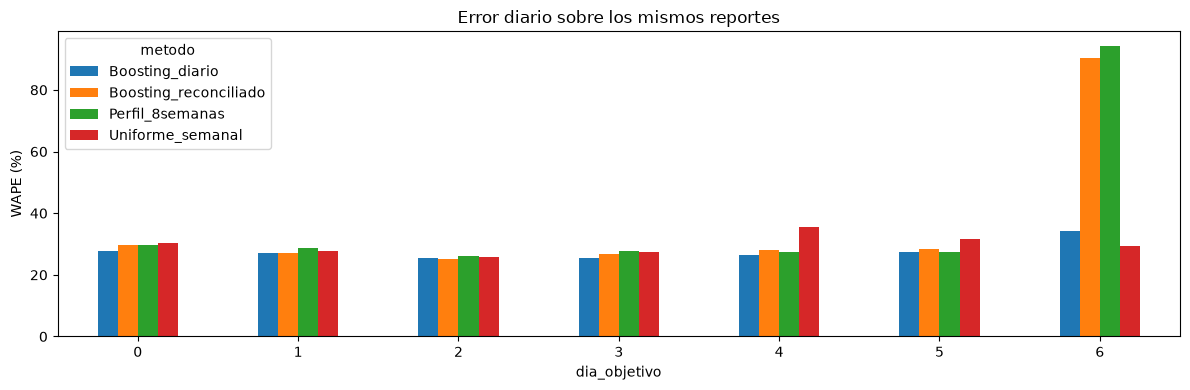

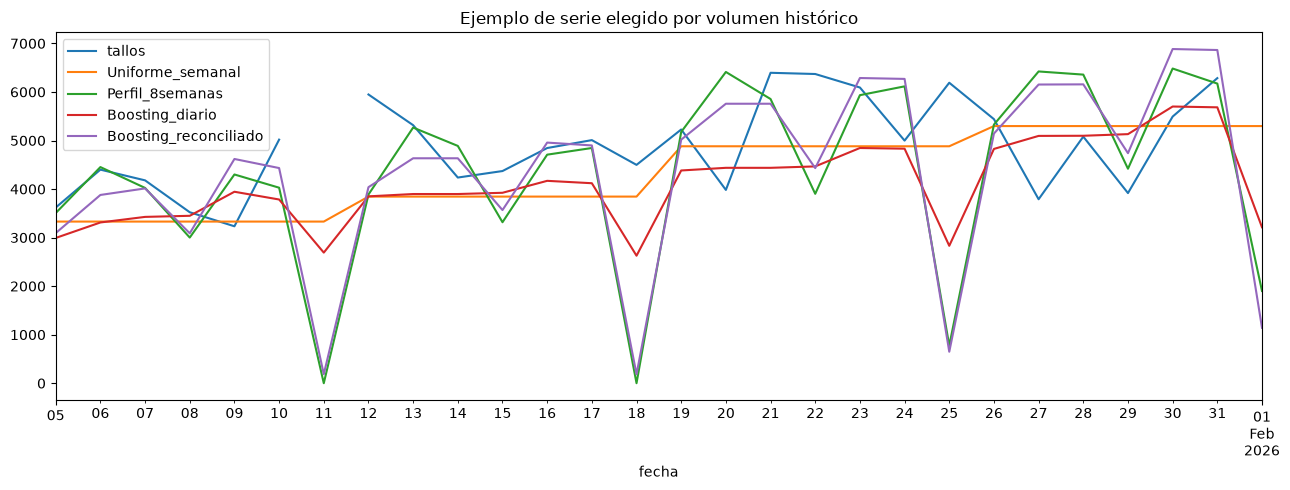

La reconciliación impone coherencia; no garantiza menor error diario ni corrige un total semanal equivocado.


In [5]:
observados=pred.loc[pred.tallos.notna()]
larga=observados.melt(id_vars=KEY+['origen','fecha','dia_objetivo','tallos'],value_vars=metodos,var_name='metodo',value_name='prediccion')
assert larga.groupby(KEY+['origen','fecha']).metodo.nunique().eq(len(metodos)).all()
def evaluar(g):
    e=g.tallos-g.prediccion
    return pd.Series({'n':len(g),'MAE':e.abs().mean(),'RMSE':np.sqrt((e**2).mean()),'WAPE':e.abs().sum()/g.tallos.sum(),'sesgo':e.mean()})
resumen=larga.groupby('metodo').apply(evaluar)
por_dia=larga.groupby(['dia_objetivo','metodo']).apply(evaluar)
por_producto=larga.groupby(['producto','metodo']).apply(evaluar)
display(resumen);display(por_dia);display(por_producto)
formas=[]
for metodo,peso in [('Uniforme_semanal',pd.Series(1/7,index=pred.index)),('Perfil_8semanas',pred.peso_perfil),('Boosting_reconciliado',pred.peso_boost)]:
    ok=pred.tallos.notna()&pred.y.gt(0)
    formas.append({'metodo':metodo,'MAE_peso_observado':(peso[ok]-pred.loc[ok,'tallos']/pred.loc[ok,'y']).abs().mean(),'masa_media_dias_sin_reporte':peso.where(pred.tallos.isna(),0).groupby([pred[c] for c in KEY+['origen']]).sum().mean()})
formas=pd.DataFrame(formas);display(formas)
por_dia.WAPE.unstack().mul(100).plot.bar(figsize=(12,4),ylabel='WAPE (%)',rot=0,title='Error diario sobre los mismos reportes');plt.tight_layout();plt.show()
# Ejemplo fijado por volumen histórico anterior a 2026, no por buen error de test.
ranking=panel.loc[panel.fecha.lt('2026-01-01')].groupby(KEY).tallos.sum().sort_values(ascending=False)
serie=ranking.index[0];ej=pred.copy()
for c,v in zip(KEY,serie):ej=ej.loc[ej[c].eq(v)]
ej=ej.sort_values('fecha').head(28)
ej.set_index('fecha')[['tallos']+metodos].plot(figsize=(13,5),title='Ejemplo de serie elegido por volumen histórico');plt.tight_layout();plt.show()
pred.to_parquet(DIARIO/'predicciones_diarias_2026.parquet',index=False)
with pd.ExcelWriter(DIARIO/'resultados_distribucion_diaria.xlsx') as writer:
    resumen.to_excel(writer,sheet_name='Resumen');por_dia.to_excel(writer,sheet_name='Dia_semana');por_producto.to_excel(writer,sheet_name='Producto');formas.to_excel(writer,sheet_name='Forma',index=False)
print('La reconciliación impone coherencia; no garantiza menor error diario ni corrige un total semanal equivocado.')


## Continuación vigente

Este experimento conserva el total semanal de 14. Para evaluar el total mejorado de 15 ejecutar diario 04, que mantiene los mismos pesos y días. Para los errores train/test del último ajuste consultar semanal 17. No sustituir silenciosamente las referencias de este notebook.